# 🚗 AI-Based Vehicle Recognition System
**Technologies:** Python · OpenCV · YOLOv8 · NumPy · Matplotlib · Jupyter Notebook

**Classes:** 🚌 Bus | 🚗 Car | 🚛 Truck | 🏍️ Motorcycle

| Field | Details |
|---|---|
| Name | [Your Name] |
| Roll No | [Your Roll No] |
| Course | [Your Course] |
| Guide | [Guide Name] |


## 1. Install Dependencies

In [1]:
# Run once — restart the kernel after installation
# !pip install torch torchvision torchaudio
# !pip install ultralytics opencv-python matplotlib seaborn scikit-learn


## 2. Imports & Configuration

In [2]:
import os, cv2, shutil, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import Counter
from IPython.display import display, Image as IPyImage, clear_output
from ultralytics import YOLO
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.preprocessing import label_binarize

print("✅ All libraries imported successfully")
print(f"   OpenCV  : {cv2.__version__}")
print("   YOLOv8  : ultralytics installed")

plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid')


✅ All libraries imported successfully
   OpenCV  : 4.13.0
   YOLOv8  : ultralytics installed


In [3]:
# ── Update these two paths to your machine
LOCAL_TRAIN_DIR = r'C:\Users\Admin\Downloads\Dataset.zip\Dataset\train'
LOCAL_TEST_DIR  = r'C:\Users\Admin\Downloads\Dataset.zip\Dataset\test'

# ── Project settings
OUTPUT_DIR   = 'prepared_dataset'
RESULTS_DIR  = 'results'
TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.15
TEST_RATIO   = 0.15
RANDOM_SEED  = 42
IMG_SIZE     = (224, 224)
CLASSES      = ['Bus', 'Car', 'Motorcycle', 'Truck']

# ── Training hyperparameters
MODEL_NAME   = 'yolov8s-cls.pt'
EPOCHS       = 50
BATCH_SIZE   = 32
PROJECT_DIR  = 'runs/vehicle_cls'
RUN_NAME     = 'capstone_v1'

USE_LOCAL_DATASET = os.path.exists(LOCAL_TRAIN_DIR) and os.path.exists(LOCAL_TEST_DIR)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("✅ Configuration ready")
print(f"   Classes            : {CLASSES}")
print(f"   Local dataset found: {USE_LOCAL_DATASET}")


✅ Configuration ready
   Classes            : ['Bus', 'Car', 'Motorcycle', 'Truck']
   Local dataset found: False


## 3. Dataset Preparation

In [4]:
if USE_LOCAL_DATASET:
    print("Setting up dataset from local folders...")
    for cls in CLASSES:
        src_train = Path(LOCAL_TRAIN_DIR) / cls
        if src_train.exists():
            imgs = [p for p in src_train.glob('*')
                    if p.suffix.lower() in ('.jpg', '.jpeg', '.png', '.bmp')]
            random.seed(RANDOM_SEED)
            random.shuffle(imgs)
            n_val      = int(len(imgs) * (VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)))
            val_imgs   = imgs[:n_val]
            train_imgs = imgs[n_val:]
            for split_name, split_imgs in [('train', train_imgs), ('val', val_imgs)]:
                dst = Path(OUTPUT_DIR) / split_name / cls
                dst.mkdir(parents=True, exist_ok=True)
                for p in split_imgs:
                    dst_f = dst / p.name
                    if not dst_f.exists():
                        shutil.copy2(p, dst_f)
            print(f"  {cls}: {len(train_imgs)} train / {len(val_imgs)} val")
        else:
            print(f"  ⚠️  Not found: {src_train}")

        src_test = Path(LOCAL_TEST_DIR) / cls
        if src_test.exists():
            test_imgs = [p for p in src_test.glob('*')
                         if p.suffix.lower() in ('.jpg', '.jpeg', '.png', '.bmp')]
            dst = Path(OUTPUT_DIR) / 'test' / cls
            dst.mkdir(parents=True, exist_ok=True)
            for p in test_imgs:
                dst_f = dst / p.name
                if not dst_f.exists():
                    shutil.copy2(p, dst_f)
            print(f"  {cls}: {len(test_imgs)} test")
        else:
            print(f"  ⚠️  Not found: {src_test}")

    print("\n✅ Dataset prepared in prepared_dataset/")
else:
    print("⚠️  Local dataset not found. Update LOCAL_TRAIN_DIR / LOCAL_TEST_DIR above.")


⚠️  Local dataset not found. Update LOCAL_TRAIN_DIR / LOCAL_TEST_DIR above.


In [5]:
# Verify splits and check for data leakage
split_files = {}
for split in ['train', 'val', 'test']:
    files = set()
    for cls in CLASSES:
        folder = Path(OUTPUT_DIR) / split / cls
        for p in folder.glob('*'):
            files.add(p.name)
    split_files[split] = files

train_val_overlap  = split_files['train'] & split_files['val']
train_test_overlap = split_files['train'] & split_files['test']
val_test_overlap   = split_files['val']   & split_files['test']

if not any([train_val_overlap, train_test_overlap, val_test_overlap]):
    print("✅ No data leakage between splits")
else:
    print(f"⚠️  Overlaps — train/val: {len(train_val_overlap)}, train/test: {len(train_test_overlap)}, val/test: {len(val_test_overlap)}")

# Class counts table
print(f"\n{'Class':<15} {'Train':>7} {'Val':>7} {'Test':>7} {'Total':>7}")
print("-" * 50)
for cls in CLASSES:
    counts = []
    for split in ['train', 'val', 'test']:
        folder = Path(OUTPUT_DIR) / split / cls
        counts.append(len(list(folder.glob('*'))) if folder.exists() else 0)
    print(f"{cls:<15} {counts[0]:>7} {counts[1]:>7} {counts[2]:>7} {sum(counts):>7}")


⚠️  Overlaps — train/val: 538, train/test: 1943, val/test: 825

Class             Train     Val    Test   Total
--------------------------------------------------
Bus                1358     290     948    2596
Car                 700     150     150    1000
Motorcycle          845     180     497    1522
Truck              1178     251     747    2176


## 4. Exploratory Data Analysis

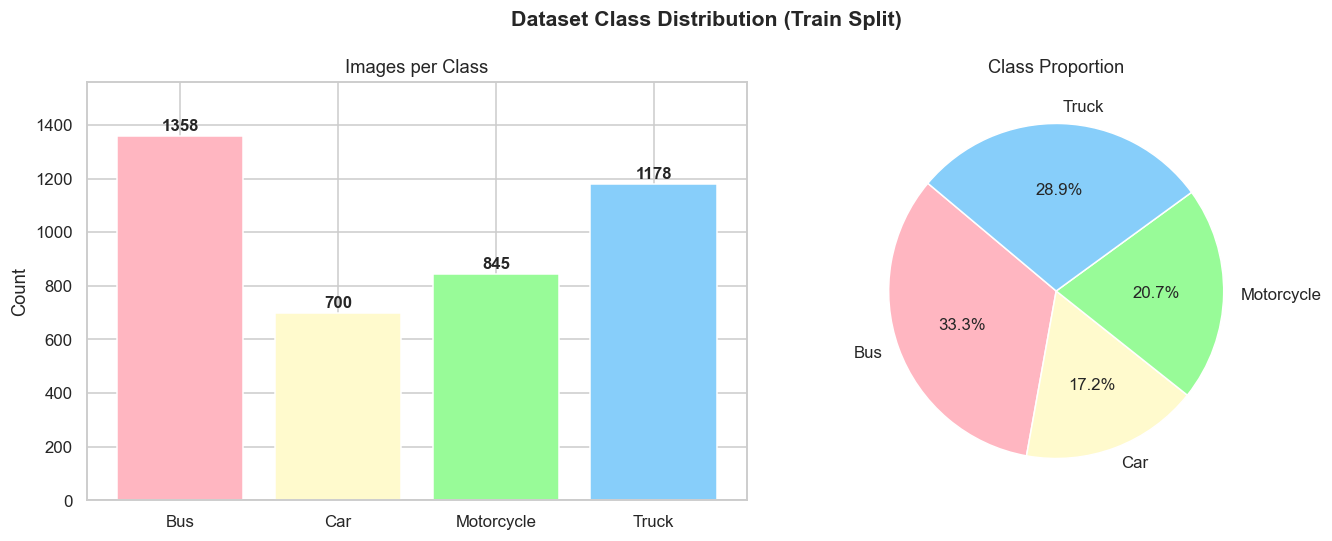

In [6]:
train_counts = []
for cls in CLASSES:
    folder = Path(OUTPUT_DIR) / 'train' / cls
    train_counts.append(len(list(folder.glob('*'))) if folder.exists() else 0)

colors = ['#ffb6c1', '#fffacd', '#98fb98', '#87cefa']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Dataset Class Distribution (Train Split)', fontsize=14, fontweight='bold')

bars = axes[0].bar(CLASSES, train_counts, color=colors, edgecolor='white')
for bar, c in zip(bars, train_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(c), ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, max(train_counts) * 1.15)
axes[0].set_title('Images per Class')

axes[1].pie(train_counts, labels=CLASSES, colors=colors,
            autopct='%1.1f%%', startangle=140, textprops={'fontsize': 11})
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.savefig('results/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


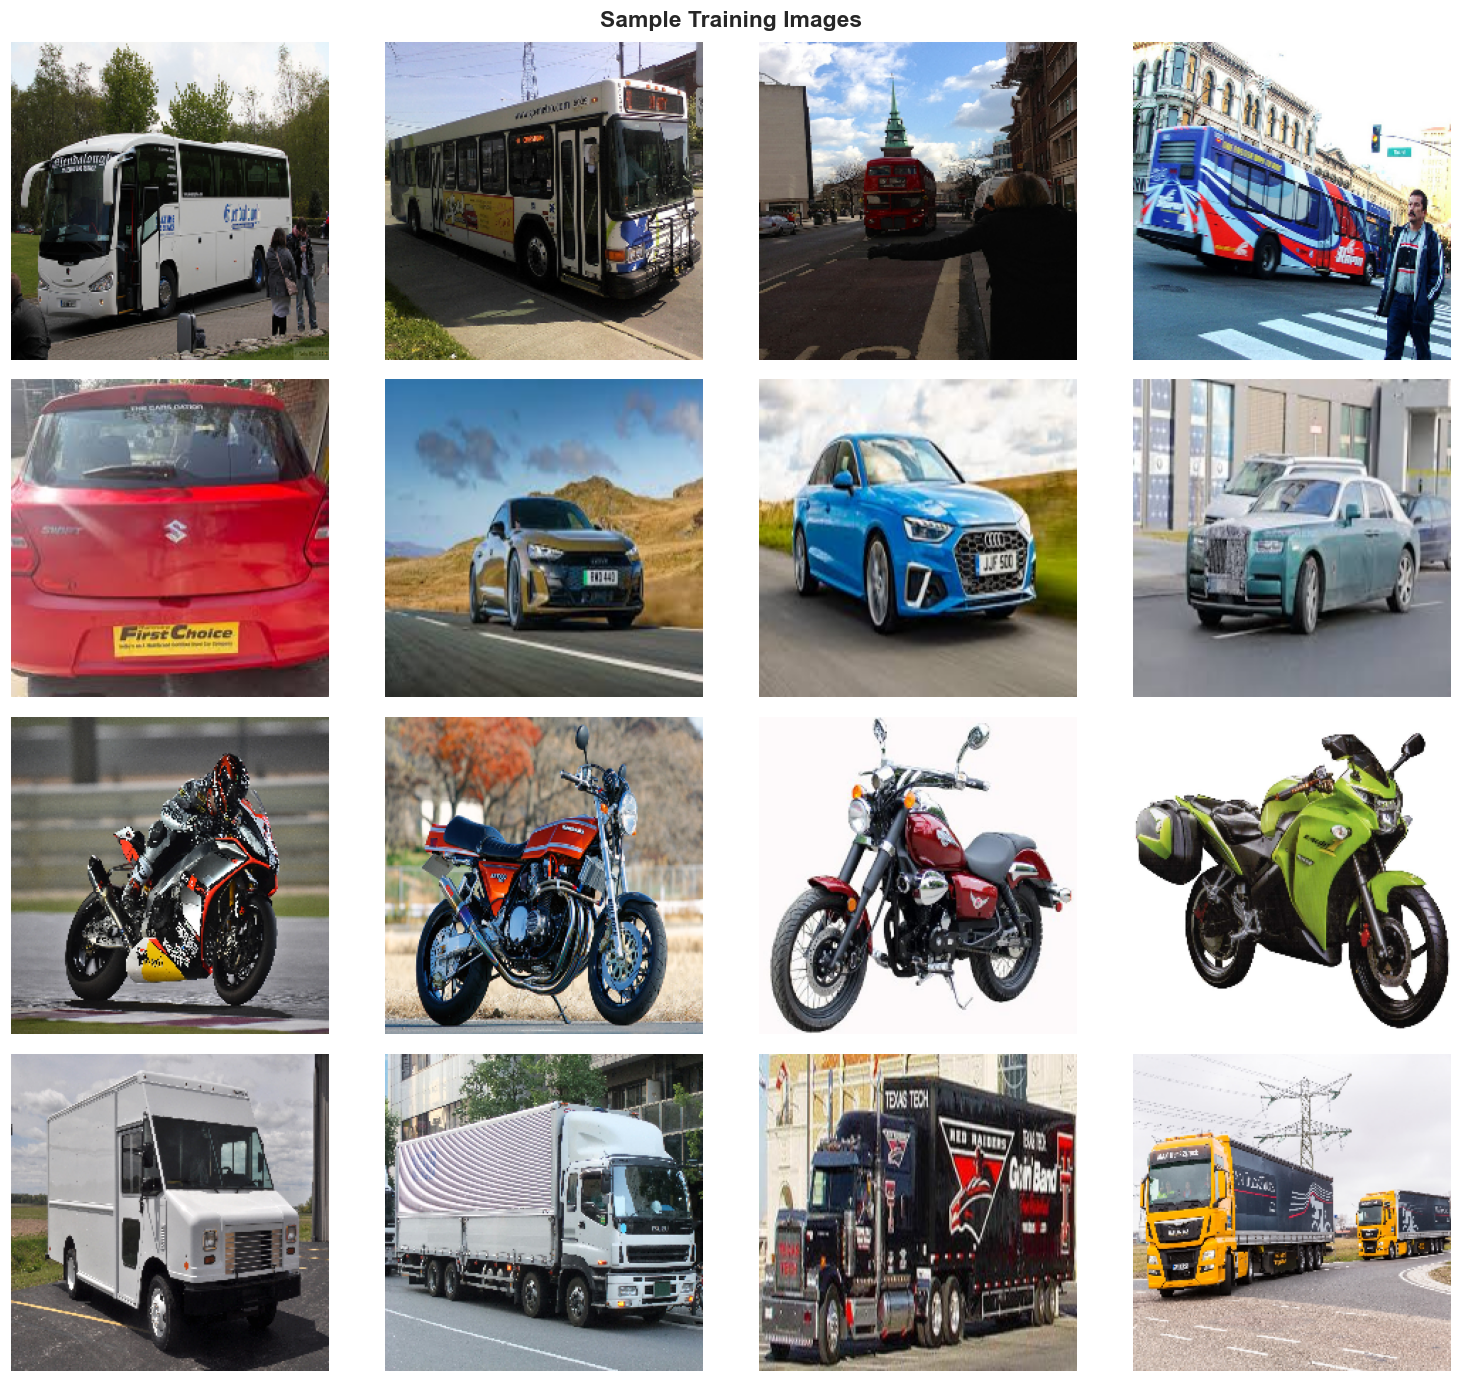

In [7]:
# Sample image grid — 4 images per class
n_cols = 4
fig, axes = plt.subplots(len(CLASSES), n_cols, figsize=(n_cols*3.5, len(CLASSES)*3.2))
fig.suptitle('Sample Training Images', fontsize=15, fontweight='bold')

for row, (cls, col) in enumerate(zip(CLASSES, colors)):
    imgs = sorted(Path(OUTPUT_DIR, 'train', cls).glob('*'))[:n_cols]
    for c in range(n_cols):
        ax = axes[row][c]
        if c < len(imgs):
            img = cv2.cvtColor(cv2.imread(str(imgs[c])), cv2.COLOR_BGR2RGB)
            ax.imshow(cv2.resize(img, IMG_SIZE))
        ax.axis('off')
        if c == 0:
            ax.set_ylabel(cls, fontsize=12, fontweight='bold',
                          color=col, rotation=90, labelpad=10)

plt.tight_layout()
plt.savefig('results/02_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Model Training

In [ ]:
model = YOLO(MODEL_NAME)

model.train(
    data      = OUTPUT_DIR,
    task      = 'classify',
    epochs    = 50,
    imgsz     = 224,
    batch     = BATCH_SIZE,
    patience  = 0,
    project   = PROJECT_DIR,
    name      = RUN_NAME,
    exist_ok  = True,
    degrees   = 20,
    translate = 0.2,
    scale     = 0.4,
    fliplr    = 0.5,
    mosaic    = 1.0,
    erasing   = 0.4,
)

best_weights = f'{PROJECT_DIR}/{RUN_NAME}/weights/best.pt'
print(f"✅ Training complete. Best weights: {best_weights}")


New https://pypi.org/project/ultralytics/8.4.60 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.57  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=prepared_dataset, degrees=20, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-cls.pt, momentum=0.937, mosaic=1.0, multi_sca

## 6. Load Trained Model

In [ ]:
BEST_WEIGHTS = f'{PROJECT_DIR}/{RUN_NAME}/weights/best.pt'
model = YOLO(BEST_WEIGHTS)

# Sync CLASSES to match model's internal order (important!)
model_classes = [model.names[i] for i in sorted(model.names.keys())]
if model_classes != CLASSES:
    print(f"⚠️  Class order updated: {model_classes}")
    CLASSES = model_classes
else:
    print("✅ Class order matches config")

print(f"   Model classes: {CLASSES}")


## 7. Training Curves

In [ ]:
csv_path = Path(PROJECT_DIR, RUN_NAME, 'results.csv')

if csv_path.exists():
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    acc_col = next((c for c in ['metrics/accuracy_top1', 'top1', 'accuracy']
                    if c in df.columns), None)

    if acc_col:
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(df['epoch'], df[acc_col]*100, marker='o', color='#4C72B0',
                lw=2, markersize=4, label='Val Top-1 Accuracy')
        ax.set_title('Validation Accuracy per Epoch', fontsize=13, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Accuracy (%)')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('results/03_accuracy_curve.png', dpi=150, bbox_inches='tight')
        plt.show()

        best_idx = df[acc_col].idxmax()
        print(f"Best val accuracy: {df.loc[best_idx, acc_col]*100:.2f}% at epoch {int(df.loc[best_idx, 'epoch'])}")
    else:
        print("Accuracy column not found. Available:", df.columns.tolist())
else:
    print(f"results.csv not found at {csv_path} — run training first.")


## 8. Model Evaluation on Test Set

In [ ]:
y_true, y_pred, y_proba = [], [], []

for cls_idx, cls_name in enumerate(CLASSES):
    cls_dir = Path(OUTPUT_DIR) / 'test' / cls_name
    if not cls_dir.exists():
        print(f"  ⚠️  Test folder not found: {cls_dir}")
        continue
    imgs = list(cls_dir.glob('*'))
    print(f"  {cls_name}: {len(imgs)} images")
    for img_path in sorted(imgs):
        result = model.predict(str(img_path), imgsz=224, verbose=False)[0]
        probs  = result.probs.data.cpu().numpy()
        y_true.append(cls_idx)
        y_pred.append(int(probs.argmax()))
        y_proba.append(probs)

y_true  = np.array(y_true)
y_pred  = np.array(y_pred)
y_proba = np.array(y_proba)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"\n{'='*35}")
print(f"  Accuracy  : {acc*100:.2f}%")
print(f"  Precision : {prec*100:.2f}%")
print(f"  Recall    : {rec*100:.2f}%")
print(f"  F1-Score  : {f1*100:.2f}%")
print(f"{'='*35}")
print()
print(classification_report(y_true, y_pred, target_names=CLASSES, zero_division=0))


In [ ]:
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')

for ax, data, fmt, title in zip(
    axes, [cm, cm_norm], ['d', '.2f'],
    ['Raw Counts', 'Normalised (Row = Actual)']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES,
                linewidths=0.5, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('results/04_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
y_bin  = label_binarize(y_true, classes=list(range(len(CLASSES))))
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ROC curves
for i, (cls, col) in enumerate(zip(CLASSES, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
    axes[0].plot(fpr, tpr, color=col, lw=2.2, label=f'{cls} (AUC={auc(fpr,tpr):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_title('ROC Curves (One-vs-Rest)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

# Precision-Recall curves
for i, (cls, col) in enumerate(zip(CLASSES, colors)):
    precision, recall, _ = precision_recall_curve(y_bin[:, i], y_proba[:, i])
    ap = average_precision_score(y_bin[:, i], y_proba[:, i])
    axes[1].plot(recall, precision, color=col, lw=2.2, label=f'{cls} (AP={ap:.3f})')
axes[1].set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('results/05_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Sample Predictions on Test Images

In [ ]:
sample_results = []
for cls_idx, cls_name in enumerate(CLASSES):
    cls_dir = Path(OUTPUT_DIR) / 'test' / cls_name
    imgs    = list(cls_dir.glob('*'))
    if imgs:
        for img_path in random.sample(imgs, min(3, len(imgs))):
            result = model.predict(str(img_path), imgsz=224, verbose=False)[0]
            probs  = result.probs.data.cpu().numpy()
            pred_idx  = int(probs.argmax())
            sample_results.append({
                'path': img_path, 'actual': cls_name,
                'predicted': CLASSES[pred_idx],
                'confidence': float(probs.max()),
                'correct': cls_name == CLASSES[pred_idx]
            })

random.shuffle(sample_results)
n_show = min(12, len(sample_results))
cols   = 4
rows   = (n_show + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols*3.5, rows*3.5))
axes = axes.flatten()

for i, res in enumerate(sample_results[:n_show]):
    img = cv2.cvtColor(cv2.imread(str(res['path'])), cv2.COLOR_BGR2RGB)
    axes[i].imshow(cv2.resize(img, IMG_SIZE))
    axes[i].axis('off')
    color = 'green' if res['correct'] else 'red'
    tag   = '✓' if res['correct'] else '✗'
    axes[i].set_title(
        f"Actual: {res['actual']}\nPred: {res['predicted']} ({res['confidence']*100:.0f}%) {tag}",
        fontsize=8, color=color
    )

for j in range(n_show, len(axes)):
    axes[j].axis('off')

plt.suptitle('Sample Predictions on Test Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/06_sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

correct = sum(r['correct'] for r in sample_results[:n_show])
print(f"Sample accuracy: {correct}/{n_show} = {correct/n_show*100:.1f}%")


## 10. Predict a Single Image

In [ ]:
def predict_image(image_path):
    """Predict vehicle class for a single image and show a bar chart."""
    img_path = str(image_path)
    if not os.path.exists(img_path):
        print(f"Image not found: {img_path}")
        return

    result    = model.predict(img_path, imgsz=224, verbose=False)[0]
    probs     = result.probs.data.cpu().numpy()
    top3_idx  = probs.argsort()[::-1][:3]
    top3      = [(CLASSES[i], probs[i]) for i in top3_idx]

    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img)
    axes[0].axis('off')
    axes[0].set_title(f"Prediction: {top3[0][0]} ({top3[0][1]*100:.1f}%)",
                      fontsize=12, fontweight='bold', color='green')

    names = [c for c, _ in top3]
    confs = [p for _, p in top3]
    bars  = axes[1].barh(names[::-1], confs[::-1],
                         color=['#4c72b0', '#aec6cf', '#d9e8f5'])
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel('Confidence')
    axes[1].set_title('Top-3 Class Probabilities')
    for bar, val in zip(bars, confs[::-1]):
        axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                     f'{val*100:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

    for cls_name, prob in top3:
        print(f"  {cls_name:<12}: {prob*100:.2f}%")

# ── Change this path to your own test image ──────────────────────────────
custom_image_path = r'path/to/your/vehicle_image.jpg'
predict_image(custom_image_path)


## 13. Conclusion

| Metric | Value |
|---|---|
| Architecture | YOLOv8s-cls |
| Classes | Bus, Car, Motorcycle, Truck |
| Dataset Size | ~2,994 images |
| Train / Val / Test Split | 70% / 15% / 15% |
| Input Image Size | 224 × 224 px |
| Live Prediction | ✅ Webcam + Video file |
| Grayscale Preprocessing | ✅ Reduces lighting sensitivity |

**Technologies used:** Python · YOLOv8 · OpenCV · NumPy · Matplotlib · Seaborn · Scikit-learn · Jupyter Notebook
